In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

In [2]:
file_path = r"C:/Users/Kanouj Bose/Downloads/archive/Mall_Customers.csv"
df = pd.read_csv(file_path)

print(df.head())

num_features = df.select_dtypes(include=[np.number]).columns.tolist()
cat_features = df.select_dtypes(include=["object"]).columns.tolist()

print(f"Numerical Features: {num_features}")
print(f"Categorical Features: {cat_features}")

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
Numerical Features: ['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Categorical Features: ['Gender']


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000         

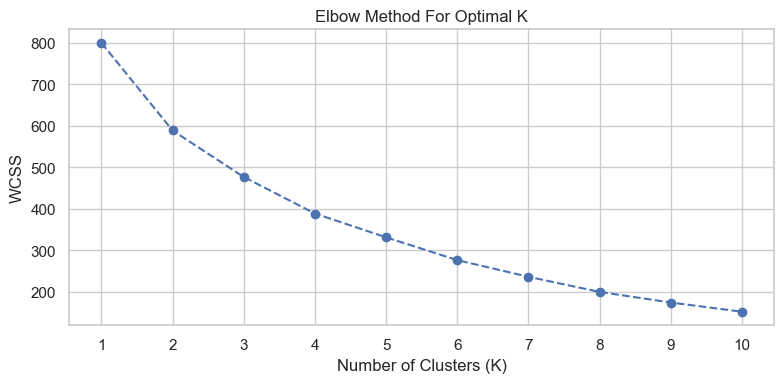

In [3]:
df.info()
print(df.describe())

print(df.isnull().sum())

df_processed = df.drop(columns=["CustomerID"])
df_processed = pd.get_dummies(
    df_processed, columns=["Gender"], drop_first=True
)

features = df_processed.columns
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_processed)

X_scaled_df = pd.DataFrame(X_scaled, columns=features)
print(X_scaled_df.head(3))

wcss = []
k_range = range(1, 11)

for k in k_range:
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  kmeans.fit(X_scaled)
  wcss.append(kmeans.inertia_)

optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

df["Cluster"] = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2)
pca_features = pca.fit_transform(X_scaled)

df["PCA1"] = pca_features[:, 0]
df["PCA2"] = pca_features[:, 1]

plt.figure(figsize=(8, 4))
plt.plot(k_range, wcss, marker="o", linestyle="--", color="b")
plt.title("Elbow Method For Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.xticks(k_range)
plt.tight_layout()
plt.show()

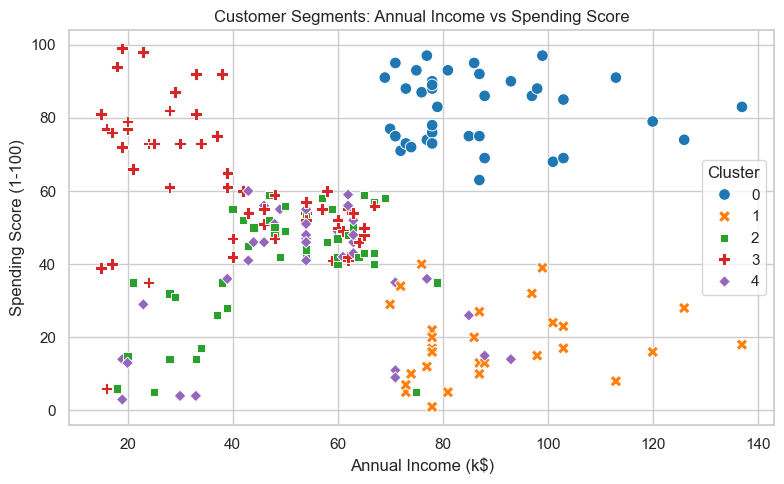

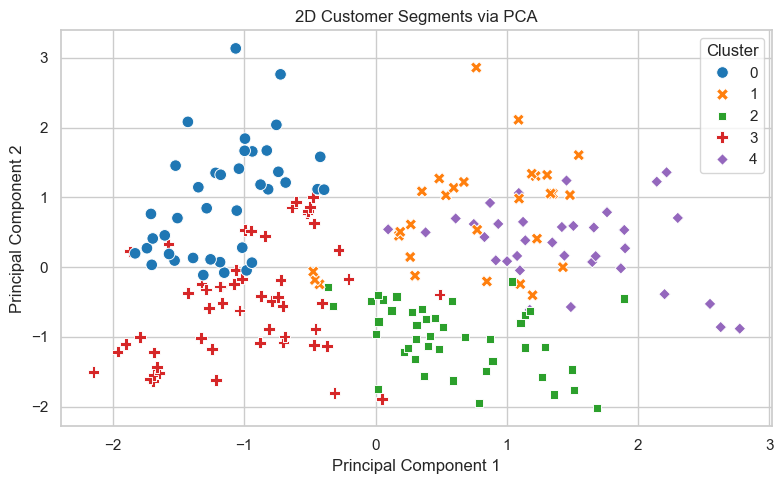

In [4]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="tab10",
    style="Cluster",
    s=70,
)
plt.title("Customer Segments: Annual Income vs Spending Score")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="tab10",
    style="Cluster",
    s=70,
)
plt.title("2D Customer Segments via PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()